In [160]:
# importing packages
import finesse
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.special


In [161]:
# creating model
model = finesse.Model()

# Setting some variables:
modf = 30e6
modf2 = 7e6

model.parse(f"""
    # Start with the cavity. Use the generating_sidebands function below to create carrier and sideband beams. 
    m inm R=0.99 T=0.01
    s scav portA=inm.p2 portB=outm.p1 L=0.5
    m outm R=0.995 T=0.005

    # Creating photodetectors:
    pd pdtrans outm.p2.o
    pd pdrefl inm.p1.o
    
    # Now for the demodulation pd. 
    # I have used preeminence to determine that the optimal phase MUST be 2 degrees
    # (actually just look ahead to see how I found the optimal phase)
    pd1 pdh node=inm.p1.o f={modf} phase=0
""")

# Find FWHM based on reflectivity of cavity mirrors.
c=3e8
cavfin = (np.pi*np.sqrt(model.inm.R * model.outm.R))/(1-model.inm.R * model.outm.R)
FWHM = c/(2*model.scav.L*cavfin)
print("FWHM: " + str(FWHM))
print("HWHM: " + str(FWHM/2))

FWHM: 1438412.4620130777
HWHM: 719206.2310065388


In [162]:
# Defining function to generate carrier and sidebands:
def generate_sidebands(model,order,moddepth,modfreq,carrierfield):
    # Checking to see if the function has already ran in the kernel.
    has_function_ran = False
    for el in model.elements:
        if el.startswith('function_use_indicator'):
            has_function_ran = True
            
    # orderrange is an array with size scaled by modulation order.     
    orderrange = np.arange(1,2*order+2)

    # This phase array will be used to correct the phases of the lasers. 
    # The correction needs to happen due to the phase shift from transmitting through beamsplitters.
    phasearr = (np.flip(orderrange) - 1)*90

    # If the function has run previously in the kernel, pass the rest of the code.
    # If not, add a "nothing" element which indicates its previous run. Also run the rest. 
    if has_function_ran==True:
        print("generate_sidebands function already ran on model. Passing!")
    else:
        model.parse(f"nothing function_use_indicator")
        
        # freqmults will be an array that contains the coefficients to multiply the mod frequency by:
        # f_n = f_0 + n f_m
        freqmults = orderrange
        for i in np.arange(0,len(freqmults)):
            if freqmults[i] % 2 != 0:
                freqmults[i] = (freqmults[i] - 1)
            if freqmults[i] == freqmults[i-1]:
                freqmults[i] = -1*freqmults[i]
        freqmults = freqmults/2
    
        # Generate 50/50 beamsplitters. One for each sideband laser. 
        for i in np.arange(1,len(orderrange)):
            model.parse(f"bs sideband_bs{i} R=0.5 T=0.5")
            
        # Generate Carrier
        model.parse(f"l carrier P={2**(len(freqmults)-1)*(sp.special.jv(0,moddepth)*carrierfield)**2} phase={-phasearr[0]}")
        
        # Link Carrier to Beamsplitters
        model.parse(f"link(carrier, sideband_bs1.p1)")
        for combiner in np.arange(2,len(freqmults)):
            model.parse(f"link(sideband_bs{combiner-1}.p3, sideband_bs{combiner}.p1)")
    
        # Generate lasers
        for i in np.arange(1,len(orderrange)):
            model.parse(f"l sideband_l{i} P={(2**(len(freqmults)-1-(i-1))*(sp.special.jv(abs(freqmults[i]),moddepth)*carrierfield)**2)} f={freqmults[i]*modfreq} phase={np.abs(freqmults[i])*90-phasearr[i]}")
    
        # Link lasers to open Beamsplitter ports
        for combiner in np.arange(1,len(freqmults)):
            model.parse(f"link(sideband_l{combiner},sideband_bs{combiner}.p4)")

    # This print function alerts the user to link the final beam splitter to the cavity or EOM
    print(f"Generated successfully. Be sure to link final beam splitter (i.e. sideband_bs{len(np.arange(1,len(orderrange)))}.p3) to the rest of your set up using the link function. It is important that you pick the correct port to link!")

In [163]:
# Defining function to check for optimal demodulation frequency within 1 degree
# Please note that you MUST type in the demod frequency in scientific notation
    # i.e. 100e6 will work, but 100M will result in a "SyntaxError: invalid decimal literal" error

def find_optimal_demod_phase(finmodel,demod_freq,verbose=True):
    # Create an array of phases from 0 to 90
    phases = np.arange(0,91,1)
    # For each angle, create a pd at that angle, and at the demod frequency
    for phase in phases:
        finmodel.parse(f"pd1 demod_pdh{phase:.0f} node=inm.p1.o f={demod_freq} phase={phase:.0f}")
    # Run the model within the slope of the error function
    out = finmodel.run("xaxis(inm.phi,lin,-1,1,2)")
    # Create an empty array
    grad=[]
    # For each angle, fill the empty array with the slope for each angle
    for phase in phases:
        var = out[f'demod_pdh{phase}']
        grad.append((var[0] - var[-1])/2*100e3)
    grad=np.array(grad)
    # Now find the array index that the max slope occurs at
    idxmax = np.argmax(np.abs(grad))
    print(f'Maximum error signal gradient occurs at {phases[idxmax]} degrees')
    # Now remove all the demodulation pds we made!
    for el in finmodel.elements:
        if el.startswith('demod_pdh'):
            finmodel.remove(el)
            if verbose==True:
                print(f'removed {el}')

In [164]:
# Creating a deepcopy of the above model to link together the components. 
# This extra layer of granularity helps, believe it or not.
onetone = model.deepcopy()

desired_order = 1

# Generate carrier and sidebands targeting onetone
generate_sidebands(onetone, desired_order, 0.9, modf, 1)

onetone.parse(f"""
    link(sideband_bs{2*desired_order}.p3,inm)
""")

Generated successfully. Be sure to link final beam splitter (i.e. sideband_bs2.p3) to the rest of your set up using the link function. It is important that you pick the correct port to link!


In [165]:
# print(onetone.elements)
print(onetone.sideband_l2.phase)

90.0 degrees


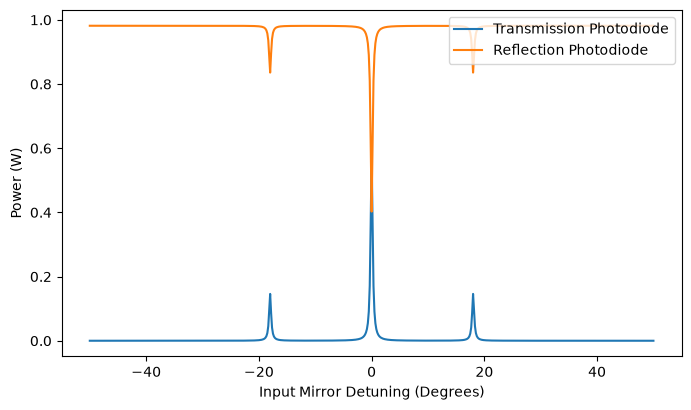

In [166]:
# Plotting mirror detuning sweep
onetone.parse("xaxis(inm.phi, lin, -50, 50, 600)")

# Run the model and create x data array
sol = onetone.run()
solxdata = np.squeeze(sol.x)  # squeeze cuts out a 1 entry array element that appears to exist to make our lives difficult

plt.figure(figsize=(8,4.5))
plt.plot(solxdata, sol["pdtrans"], label="Transmission Photodiode")
plt.plot(solxdata, sol["pdrefl"], label="Reflection Photodiode")
plt.xlabel("Input Mirror Detuning (Degrees)")
plt.ylabel("Power (W)")
plt.legend(loc = "upper right")


In [167]:
# Determining optimal Demodualtion phase
find_optimal_demod_phase(onetone,10e6,verbose=False)

Maximum error signal gradient occurs at 0 degrees


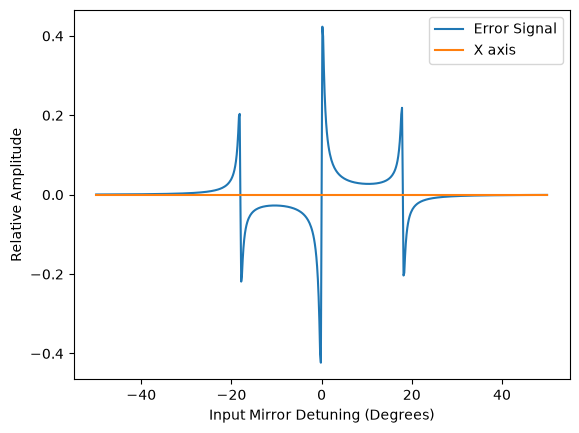

In [168]:
# Plotting error function
plt.plot(solxdata, sol["pdh"], label="Error Signal")
plt.plot(solxdata,np.zeros(len(solxdata)),label="X axis")
plt.legend(loc='upper right')
plt.xlabel("Input Mirror Detuning (Degrees)")
plt.ylabel("Relative Amplitude")
plt.show()

In [169]:
# Creating a deepcopy of model to add in more modulators, and a pd2
twotone = model.deepcopy()

twotone.parse(f"""
    # add in the modulators
    mod pm2 {modf2} 0.9 order=2 mod_type=pm phase=0.0
    mod am2 pm2.f 0.1 order=1 mod_type=am phase=0.0
    
    # ... and a new photodiode 
    # pd2 demodulates at the first frequency, then the second
    pd2 pdh2tone inm.p1.o {modf} 1 2*{modf2} 0
""")

In [170]:
generate_sidebands(twotone, desired_order, 0.9, modf, 1)

twotone.parse(f"link(sideband_bs{2*desired_order}.p3,pm2,am2,inm)")

Generated successfully. Be sure to link final beam splitter (i.e. sideband_bs2.p3) to the rest of your set up using the link function. It is important that you pick the correct port to link!


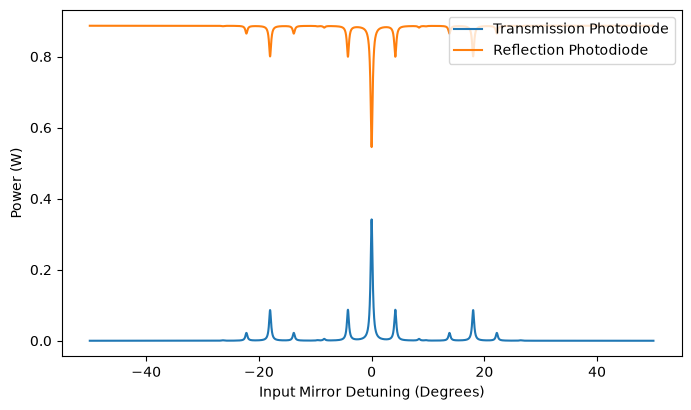

In [178]:
twotone.parse("xaxis(inm.phi, lin, -50, 50, 6000)")

sol2tone = twotone.run()
sol2tonexdata = np.squeeze(sol2tone.x)

plt.figure(figsize=(8,4.5))
plt.plot(sol2tonexdata, sol2tone["pdtrans"], label="Transmission Photodiode")
plt.plot(sol2tonexdata, sol2tone["pdrefl"], label="Reflection Photodiode")
plt.xlabel("Input Mirror Detuning (Degrees)")
plt.ylabel("Power (W)")
plt.legend(loc = "upper right")

In [179]:
find_optimal_demod_phase(twotone, modf, verbose=False)

Maximum error signal gradient occurs at 1 degrees


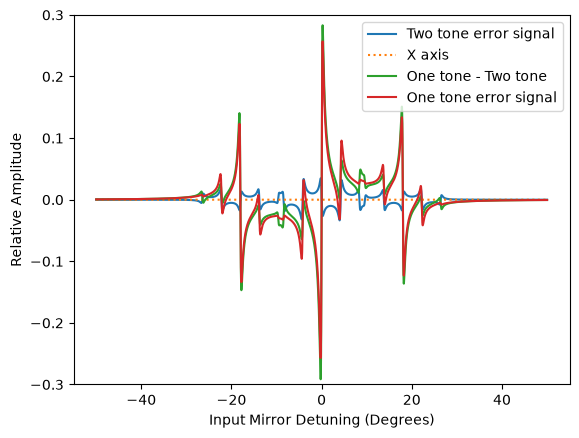

In [180]:
plt.plot(sol2tonexdata, sol2tone["pdh2tone"], label="Two tone error signal")
plt.plot(sol2tonexdata,np.zeros(len(sol2tonexdata)), label="X axis",linestyle="dotted")
plt.plot(sol2tonexdata,sol2tone["pdh"]-sol2tone["pdh2tone"], label="One tone - Two tone")
plt.plot(sol2tonexdata,sol2tone["pdh"], label="One tone error signal")
plt.ylim(-0.3,0.3)
plt.xlabel("Input Mirror Detuning (Degrees)")
plt.ylabel("Relative Amplitude")
plt.legend(loc="upper right")
plt.show()

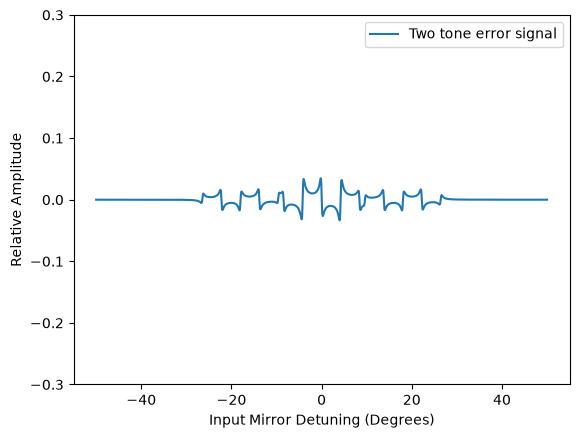

In [181]:
plt.plot(sol2tonexdata, sol2tone["pdh2tone"], label="Two tone error signal")
plt.ylim(-0.3,0.3)
plt.legend(loc="upper right")

plt.xlabel("Input Mirror Detuning (Degrees)")
plt.ylabel("Relative Amplitude")
plt.show()

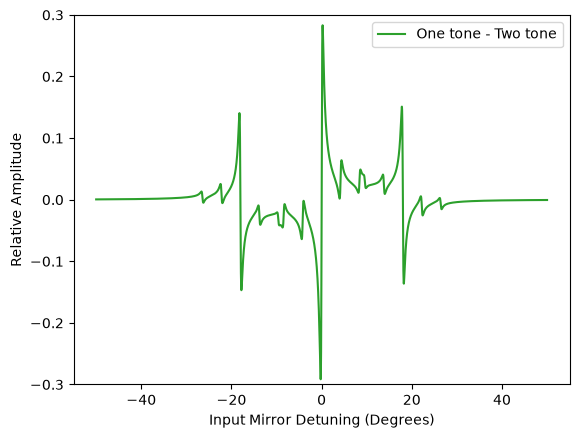

In [182]:
plt.plot(sol2tonexdata,sol2tone["pdh"]-sol2tone["pdh2tone"], label="One tone - Two tone",color="tab:green")
plt.ylim(-0.3,0.3)
plt.legend(loc="upper right")

plt.xlabel("Input Mirror Detuning (Degrees)")
plt.ylabel("Relative Amplitude")
plt.show()

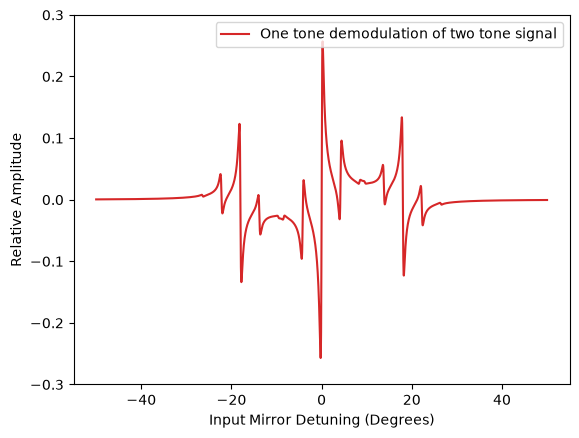

In [183]:
plt.plot(sol2tonexdata,sol2tone["pdh"], label="One tone demodulation of two tone signal",color="tab:red")
plt.ylim(-0.3,0.3)
plt.legend(loc="upper right")

plt.xlabel("Input Mirror Detuning (Degrees)")
plt.ylabel("Relative Amplitude")
plt.show()

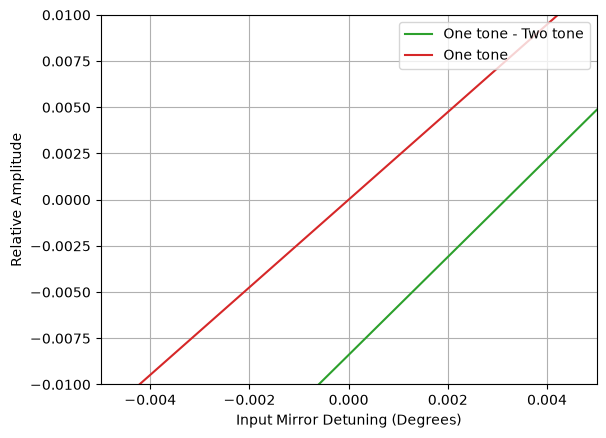

In [188]:
plt.plot(sol2tonexdata,sol2tone["pdh"]-sol2tone["pdh2tone"], label="One tone - Two tone",color="tab:green")
plt.plot(sol2tonexdata,sol2tone["pdh"], label="One tone",color="tab:red")
plt.ylim(-0.01,0.01)
plt.xlim(-0.005,0.005)
plt.legend(loc="upper right")

plt.xlabel("Input Mirror Detuning (Degrees)")
plt.ylabel("Relative Amplitude")
plt.grid()
plt.show()
